# Air Quality Index (AQI) Prediction

This notebook trains and evaluates the model used by the Flask API in `app.py`.

**Workflow:**
1. Load the dataset
2. Explore the data
3. Clean the data
4. Select features and target
5. Split into train/test sets
6. Train a Random Forest Regressor
7. Evaluate the Random Forest model
8. Compare against a Linear Regression baseline
9. Visualize results
10. Save the trained model to `model/aqi_model.pkl`

## 1. Load the Data

In [1]:
import pandas as pd

df = pd.read_csv("../data/air_quality.csv")
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


## 2. Explore the Data

In [2]:
print("Shape:", df.shape)
df.isna().sum()

Shape: (29531, 16)


City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

## 3. Clean the Data

We drop rows that have a missing value in **any** column. This is a strict
approach: it only keeps rows where every pollutant reading *and* the AQI
target are present, which significantly reduces the dataset size. It keeps
the modeling pipeline simple and matches the data the deployed model
(`model/aqi_model.pkl`) was trained on.

In [3]:
df_clean = df.dropna()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))

Rows before cleaning: 29531
Rows after cleaning: 6236


## 4. Select Features and Target

In [4]:
FEATURES = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]
TARGET = "AQI"

X = df_clean[FEATURES]
y = df_clean[TARGET]

## 5. Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4988
Testing samples: 1248


## 6. Train the Random Forest Model

In [6]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Evaluate the Random Forest Model

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

rf_predictions = model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2 Score:", rf_r2)

Random Forest MAE: 14.841514423076923
Random Forest R2 Score: 0.9444715122855026


## 8. Baseline: Linear Regression\n\nFor context, we compare the Random Forest against a simple Linear Regression model.

In [8]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression MAE: 18.6237035497145
Linear Regression R2 Score: 0.9179683814088222


## 9. Visualizations\n\n### Actual vs Predicted AQI

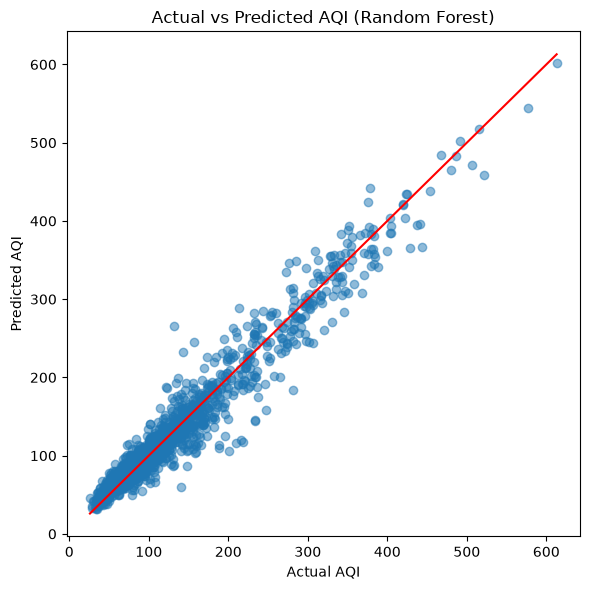

In [9]:
import os
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Random Forest)")
plt.tight_layout()
plt.savefig("../images/actual_vs_predicted.png", dpi=120)
plt.show()

### Feature Importance

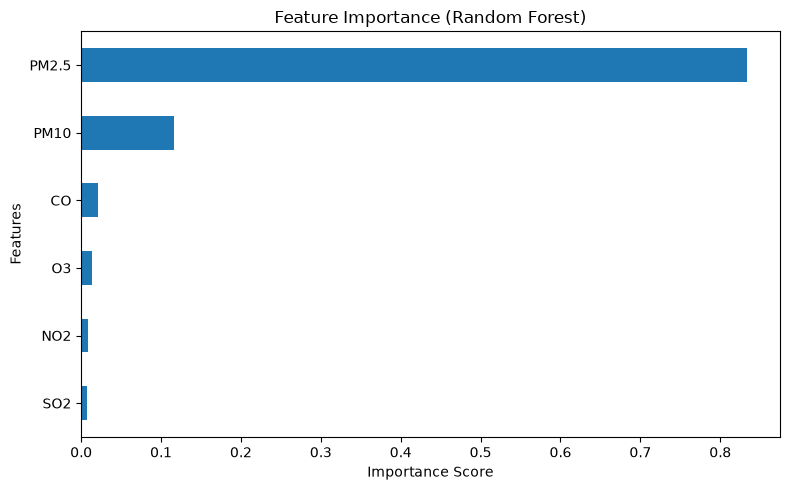

In [10]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("../images/feature_importance.png", dpi=120)
plt.show()

## 10. Save the Trained Model

The trained model is saved to `model/aqi_model.pkl`, which is loaded by
`app.py` to serve predictions via the Flask API.

In [11]:
import pickle

MODEL_PATH = os.path.join("..", "model", "aqi_model.pkl")
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)

print("Model saved to:", MODEL_PATH)
print("Saved model size (bytes):", os.path.getsize(MODEL_PATH))

Model saved to: ../model/aqi_model.pkl
Saved model size (bytes): 41920282
